# 09 – Final Model Evaluation

Provides the project's definitive performance estimate for XGBoost (Tuned) — the best model overall (F1: 0.4893, ROC-AUC: 0.6688) from Notebook 06. Two complementary evaluations are performed:

1. **Stratified cross-validation on the full training set** — a more robust performance estimate than the single 80/20 split used in earlier notebooks, as it averages over five different splits
2. **Churn probability predictions on the holdout set** — the holdout contains no ground-truth labels (competition format), so metric computation is not possible; instead, the predicted probability distribution is reported to confirm the model produces well-calibrated, plausible churn scores on unseen data

**Inputs:** Full training data from Notebook 02 · Holdout features from Notebook 02 · Best model configuration from Notebook 06

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, make_scorer
)
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

BASE_DIR = Path("..").resolve()
PROCESSED_DIR = BASE_DIR / "data" / "processed"

## Load Data

Full training set and holdout features loaded from Notebook 02 outputs.

In [2]:
X_train_full = pd.read_csv(PROCESSED_DIR / "cell2celltrain_processed.csv")
y_train_full = pd.read_csv(PROCESSED_DIR / "cell2celltrain_target.csv").squeeze("columns")
X_holdout    = pd.read_csv(PROCESSED_DIR / "cell2cellholdout_processed.csv")

print("Training features:", X_train_full.shape)
print("Training target:  ", y_train_full.shape)
print("Holdout features: ", X_holdout.shape)
print("\nTraining class distribution:")
print(y_train_full.value_counts(normalize=True).round(4))

Training features: (51047, 50)
Training target:   (51047,)
Holdout features:  (20000, 50)

Training class distribution:
Churn
0    0.7118
1    0.2882
Name: proportion, dtype: float64


## Stratified Cross-Validation — Full Training Set

Random under-sampling and model training are wrapped in an `imblearn` Pipeline to prevent data leakage across folds — resampling is applied only within each training fold, not to the validation fold. Five-fold stratified CV matches the setup used in Notebooks 05 and 06, and averaging across folds gives a more stable performance estimate than a single split.

In [3]:
pipeline = Pipeline([
    ("undersample", RandomUnderSampler(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=1.0,
        gamma=1.0,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "precision": make_scorer(precision_score, zero_division=0),
    "recall":    make_scorer(recall_score, zero_division=0),
    "f1":        make_scorer(f1_score, zero_division=0),
    "roc_auc":   make_scorer(roc_auc_score, response_method="predict_proba")
}

cv_results = cross_validate(
    pipeline, X_train_full, y_train_full,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("=== Cross-Validation Results (5-fold) — XGBoost (Tuned) ===")
for metric in ["precision", "recall", "f1", "roc_auc"]:
    scores = cv_results[f"test_{metric}"]
    print(f"  {metric:<12}: {scores.mean():.4f} ± {scores.std():.4f}  (folds: {np.round(scores, 4)})")

=== Cross-Validation Results (5-fold) — XGBoost (Tuned) ===
  precision   : 0.3942 ± 0.0045  (folds: [0.3892 0.3885 0.3959 0.3979 0.3996])
  recall      : 0.6630 ± 0.0105  (folds: [0.6595 0.654  0.6584 0.6594 0.6835])
  f1          : 0.4944 ± 0.0059  (folds: [0.4895 0.4875 0.4944 0.4963 0.5044])
  roc_auc     : 0.6747 ± 0.0055  (folds: [0.6716 0.6653 0.6782 0.6802 0.6782])


## Cross-Validation vs Test-Set Comparison

The cross-validation results are compared against the single test-set metrics reported in Notebook 06. Close agreement confirms the earlier results were not the product of a favourable split.

In [4]:
# XGBoost (Tuned) test-set results from Notebook 06
test_set_metrics = {
    "Precision": 0.3887,
    "Recall":    0.6601,
    "F1-score":  0.4893,
    "ROC-AUC":   0.6688
}

cv_mean_metrics = {
    "Precision": round(cv_results["test_precision"].mean(), 4),
    "Recall":    round(cv_results["test_recall"].mean(), 4),
    "F1-score":  round(cv_results["test_f1"].mean(), 4),
    "ROC-AUC":   round(cv_results["test_roc_auc"].mean(), 4)
}

comparison = pd.DataFrame({
    "Test Set — NB06": test_set_metrics,
    "5-Fold CV (mean)": cv_mean_metrics
}).T

print("=== Test Set vs Cross-Validation — XGBoost (Tuned) ===")
print(comparison.to_string())

=== Test Set vs Cross-Validation — XGBoost (Tuned) ===
                  Precision  Recall  F1-score  ROC-AUC
Test Set — NB06      0.3887  0.6601    0.4893   0.6688
5-Fold CV (mean)     0.3942  0.6630    0.4944   0.6747


## Retrain on Full Training Set

The final model is retrained on all available training data before generating holdout predictions. This maximises the data available to the model and is standard practice before applying a model to new, unseen data.

In [5]:
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train_full, y_train_full)

xgb_final = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=1.0,
    gamma=1.0,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_final.fit(X_train_res, y_train_res)

print(f"Model trained on {X_train_res.shape[0]} samples ({y_train_res.sum()} churners, {(y_train_res == 0).sum()} non-churners).")

Model trained on 29422 samples (14711 churners, 14711 non-churners).


## Holdout Predictions

The holdout set is a competition-format dataset with no ground-truth labels. Metric computation is therefore not possible. The predicted churn probability distribution is reported instead — a unimodal distribution skewed towards lower probabilities is expected and indicates well-calibrated predictions.

=== Holdout Predictions ===
  Total customers    : 20000
  Predicted churners : 9747 (48.7%)
  Mean churn prob    : 0.4820
  Median churn prob  : 0.4956


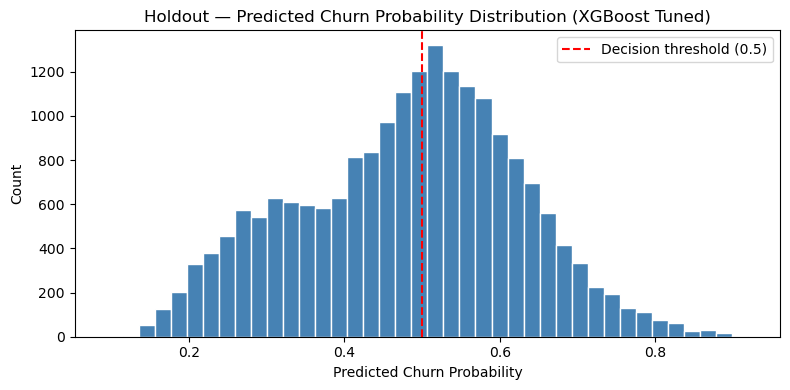

In [6]:
y_prob_holdout = xgb_final.predict_proba(X_holdout)[:, 1]
y_pred_holdout = xgb_final.predict(X_holdout)

print("=== Holdout Predictions ===")
print(f"  Total customers    : {len(y_pred_holdout)}")
print(f"  Predicted churners : {y_pred_holdout.sum()} ({y_pred_holdout.mean()*100:.1f}%)")
print(f"  Mean churn prob    : {y_prob_holdout.mean():.4f}")
print(f"  Median churn prob  : {np.median(y_prob_holdout):.4f}")

# Plot predicted probability distribution
plt.figure(figsize=(8, 4))
plt.hist(y_prob_holdout, bins=40, edgecolor="white", color="steelblue")
plt.axvline(0.5, color="red", linestyle="--", label="Decision threshold (0.5)")
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Count")
plt.title("Holdout — Predicted Churn Probability Distribution (XGBoost Tuned)")
plt.legend()
plt.tight_layout()
plt.show()

## Key Observations

**Cross-validation vs test-set comparison — XGBoost (Tuned):**

| Evaluation | Precision | Recall | F1-score | ROC-AUC |
|---|---|---|---|---|
| Test Set — NB06 (single 80/20 split) | 0.3887 | 0.6601 | 0.4893 | 0.6688 |
| **5-Fold CV — Full Training Set** | **0.3942 ± 0.005** | **0.6630 ± 0.011** | **0.4944 ± 0.006** | **0.6747 ± 0.006** |

The CV mean slightly exceeds the single test-set result across all metrics, which is expected when training on the full dataset (more data = marginally stronger model). The close agreement confirms no overfitting to a particular split and validates the model selection process from Notebooks 04–06.

**Holdout predictions:**

| Metric | Value |
|---|---|
| Total customers | 20,000 |
| Predicted churners | 9,747 (48.7%) |
| Mean churn probability | 0.4820 |
| Median churn probability | 0.4956 |

The predicted churn rate of 48.7% is higher than the training distribution (approx. 29%). This is expected — the model was retrained on under-sampled data (50/50 class balance), which shifts the model's decision boundary and leads to more aggressive churn predictions at the default 0.5 threshold. For production use, the decision threshold should be calibrated against the true class prior (0.29). This can be done by selecting a threshold from the ROC curve that reflects the desired precision/recall trade-off, or by using `predict_proba` scores directly and applying a lower threshold (e.g. 0.3) to better reflect real-world churn rates.